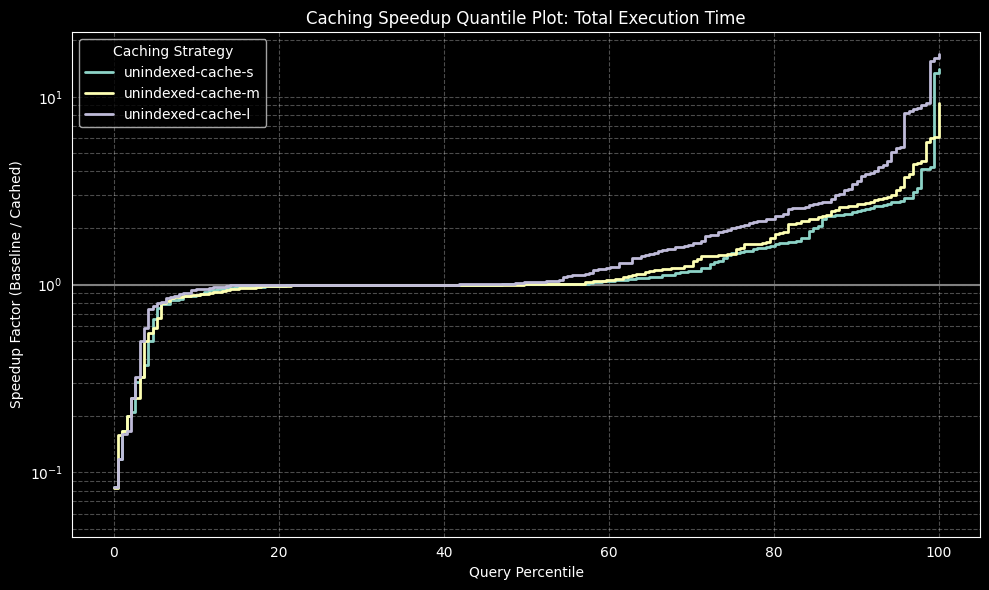

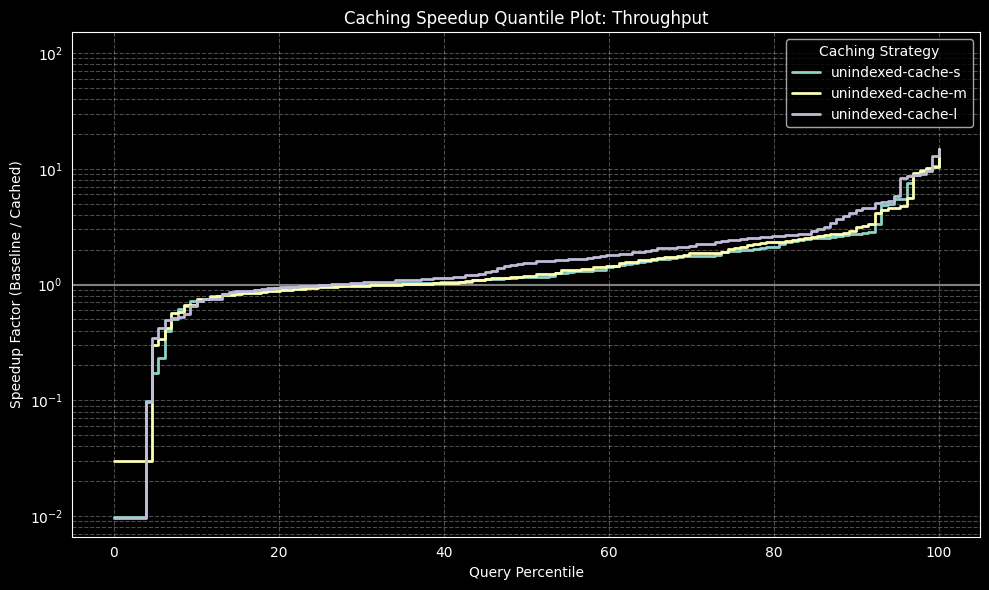

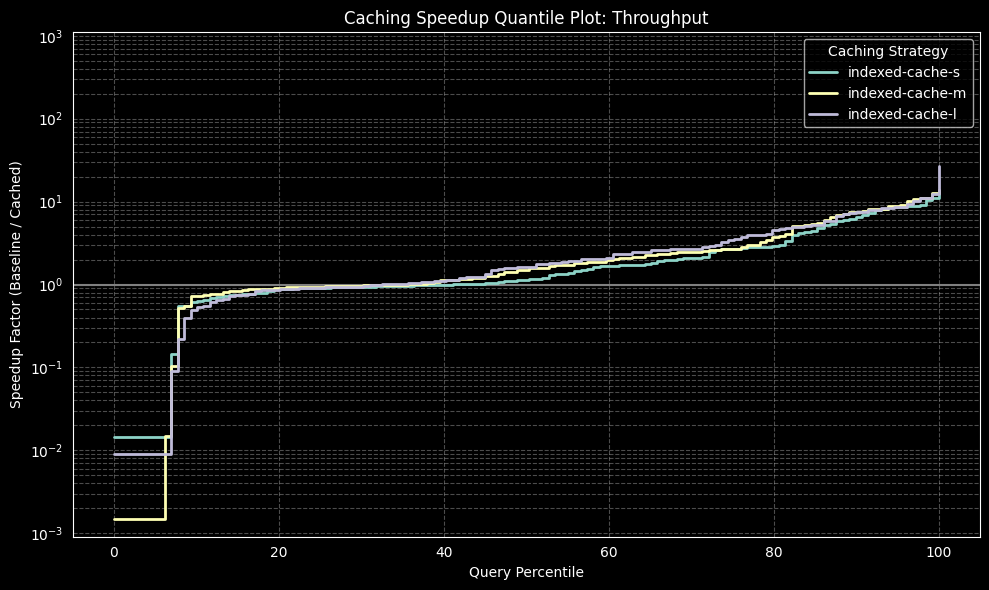

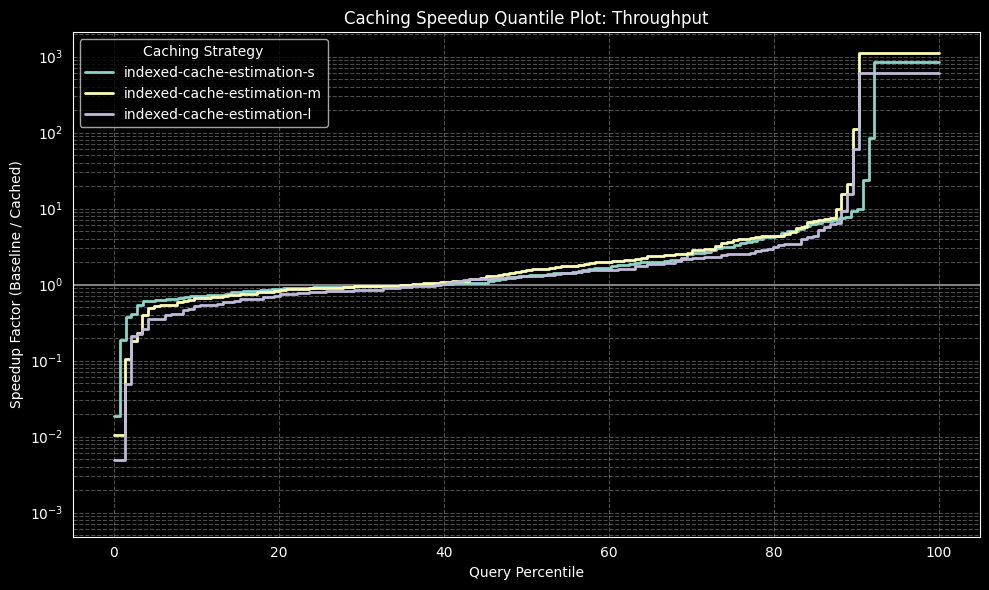

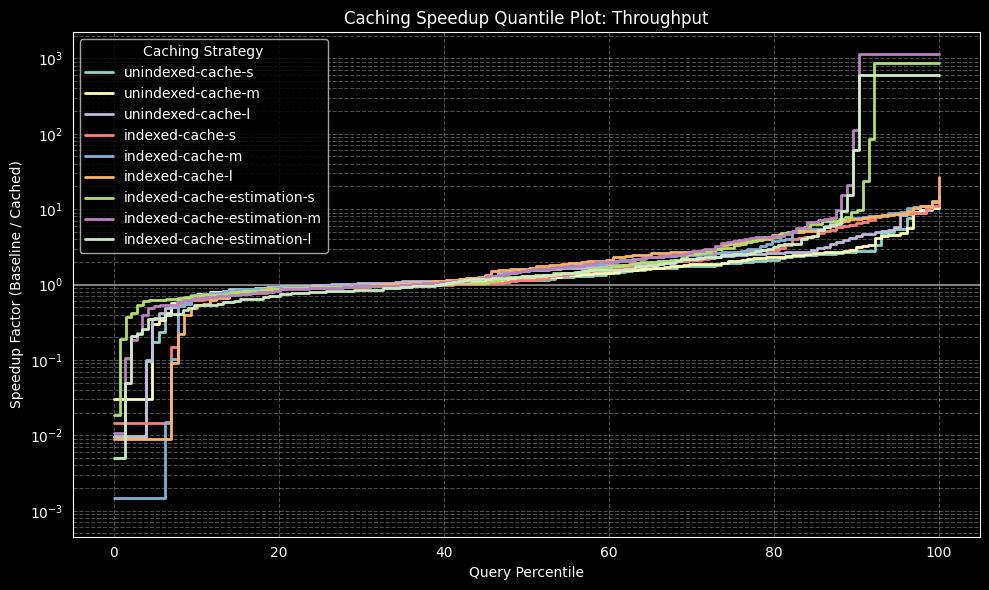

In [11]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_speedup_from_locations(baseline_locations, cache_locations, metric='time', log_scale=True, algorithm_labels=None, save_location=None):
    """
    Plots a logarithmic inverted ECDF comparing multiple caching strategies.
    Supports latency and throughput-normalized speedups.
    Valid 'metric' options: 'time', 'first_ts', 'last_ts', 'throughput'

    Parameters:
    - baseline_locations: List of file paths to baseline data.
    - cache_locations: List of file paths to cache evaluation data.
    - metric: The evaluation metric to calculate speedup against.
    - log_scale: Boolean to apply logarithmic scaling to the Y-axis.
    - algorithm_labels: Optional list of strings matching the length of cache_locations for legend labeling.
    - save_location: Optional file path string to save the resulting PDF/PNG.
    """

    def parse_file(filepath):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                timestamps = item.get('timestamps', [])

                first_ts = timestamps[0] if timestamps else None
                last_ts = timestamps[-1] if timestamps else None
                num_results = len(timestamps)

                throughput = 0.0
                if num_results > 0 and last_ts and last_ts > 0:
                    throughput = num_results / last_ts

                records.append({
                    'name': item.get('name'),
                    'id': item.get('id'),
                    'template': item.get('sequenceElement', {}).get('template', 'unknown'),
                    'time': item.get('time'),
                    'first_ts': first_ts,
                    'last_ts': last_ts,
                    'num_results': num_results,
                    'throughput': throughput
                })
        return pd.DataFrame(records)

    # 1. Process Baseline Data
    df_base_list = [parse_file(loc) for loc in baseline_locations]
    df_base = pd.concat(df_base_list, ignore_index=True)

    df_base_agg = df_base.groupby(['name', 'id', 'template']).agg({
        'time': 'median',
        'first_ts': 'median',
        'last_ts': 'median',
        'num_results': 'median',
        'throughput': 'median'
    }).reset_index()

    fig, ax = plt.subplots(figsize=(10, 6))

    # 2. Process Each Cache Strategy
    for i, cache_loc in enumerate(cache_locations):
        # Resolve strategy label
        if algorithm_labels and i < len(algorithm_labels):
            strategy_label = algorithm_labels[i]
        else:
            strategy_label = os.path.basename(cache_loc).replace('.json', '')

        df_cache = parse_file(cache_loc)
        df_cache_agg = df_cache.groupby(['name', 'id', 'template']).agg({
            'time': 'median',
            'first_ts': 'median',
            'last_ts': 'median',
            'num_results': 'median',
            'throughput': 'median'
        }).reset_index()

        merged = pd.merge(df_base_agg, df_cache_agg, on=['name', 'id', 'template'], suffixes=('_base', '_cache'))

        safe_base_results = np.maximum(1, merged['num_results_base'])
        safe_cache_results = np.maximum(1, merged['num_results_cache'])

        # 3. Calculate Speedup
        if metric == 'first_ts':
            valid_mask = (merged['num_results_base'] > 0) & (merged['num_results_cache'] > 0)
            merged = merged[valid_mask].copy()
            merged['speedup'] = merged['first_ts_base'] / merged['first_ts_cache']

        elif metric == 'throughput':
            tb = merged['throughput_base']
            tc = merged['throughput_cache']

            # Keep queries where at least one succeeded
            valid_mask = (tb > 0) | (tc > 0)
            merged = merged[valid_mask].copy()

            tb = merged['throughput_base']
            tc = merged['throughput_cache']

            # Identify the three categories
            both_succeeded = (tb > 0) & (tc > 0)
            rescued_by_cache = (tb == 0) & (tc > 0)
            broken_by_cache = (tb > 0) & (tc == 0)

            # Calculate normal speedups to find natural bounds
            normal_speedups = tc[both_succeeded] / tb[both_succeeded]

            max_normal = normal_speedups.max() if not normal_speedups.empty else 10.0
            min_normal = normal_speedups.min() if not normal_speedups.empty else 0.1

            # Create distinct ledges (1 order of magnitude beyond max/min)
            infinity_proxy = max_normal * 10.0
            zero_proxy = min_normal / 10.0

            # Assign speedups categorically
            speedup_col = pd.Series(index=merged.index, dtype=float)
            speedup_col[both_succeeded] = normal_speedups
            speedup_col[rescued_by_cache] = infinity_proxy
            speedup_col[broken_by_cache] = zero_proxy

            merged['speedup'] = speedup_col

        elif metric in ['time', 'last_ts']:
            latency_ratio = merged[f'{metric}_base'] / merged[f'{metric}_cache']
            result_ratio = safe_cache_results / safe_base_results
            merged['speedup'] = latency_ratio * result_ratio

        else:
            raise ValueError("Invalid metric. Choose 'time', 'first_ts', 'last_ts', or 'throughput'.")

        speedups = merged['speedup'].dropna().values
        speedups = speedups[speedups > 0]
        speedups.sort()

        if len(speedups) > 0:
            percentiles = np.linspace(0, 100, len(speedups))
            ax.step(percentiles, speedups, where='post', linewidth=2, label=strategy_label)

    # 4. Apply Graph Formatting
    ax.axhline(1.0, color='gray', linestyle='-', linewidth=1.5, zorder=1)

    if log_scale:
        ax.set_yscale('log')
        ymin, ymax = ax.get_ylim()

        if ymin > 0 and ymax > 0:
            max_log_dev = max(abs(np.log10(ymin)), abs(np.log10(ymax)))
            ax.set_ylim(10 ** (-max_log_dev), 10 ** max_log_dev)

    metric_labels = {
        'time': 'Total Execution Time',
        'first_ts': 'First Result Arrival Time',
        'last_ts': 'Last Result Arrival Time',
        'throughput': 'Throughput'
    }
    display_metric = metric_labels.get(metric, metric)

    ax.set_xlabel('Query Percentile')
    ax.set_ylabel('Speedup Factor (Baseline / Cached)')
    ax.set_title(f'Caching Speedup Quantile Plot: {display_metric}')

    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend(title="Caching Strategy")

    plt.tight_layout()

    # 5. Save and Display
    if save_location:
        output_dir = os.path.dirname(save_location)
        if output_dir:
            os.makedirs(output_dir, exist_ok=True)
        plt.savefig(save_location, bbox_inches='tight')
        print(f"Plot successfully saved to: {save_location}")

    plt.show()

def get_algorithm_labels(locations):
    """
    Takes a list of file paths and returns a list of formatted algorithm labels.
    """
    def map_single(location_string):
        filename = os.path.basename(location_string).replace('.json', '')
        clean_name = filename.replace('query-results-raw-', '')

        # Extract size suffix and base algorithm name
        if clean_name[-2:].lower() in ['-s', '-m', '-l']:
            size = clean_name[-1].lower()
            base_type = clean_name[:-2]
        else:
            return clean_name  # Fallback if no valid size suffix exists

        # Apply mapping rules
        mapping = {
            'cache': 'unindexed-cache',
            'query-cache': 'indexed-cache',
            'query-cache-estimate': 'indexed-cache-estimation'
        }

        mapped_type = mapping.get(base_type, base_type)
        return f"{mapped_type}-{size}"

    return [map_single(loc) for loc in locations]


if __name__ == "__main__":
    raw_data_cache_s = os.path.join("..", "data", "query-results-raw-cache-s.json")
    raw_data_cache_m = os.path.join("..", "data", "query-results-raw-cache-m.json")
    raw_data_cache_l = os.path.join("..", "data", "query-results-raw-cache-l.json")

    raw_data_query_cache_s = os.path.join("..", "data", "query-results-raw-query-cache-s.json")
    raw_data_query_cache_m = os.path.join("..", "data", "query-results-raw-query-cache-m.json")
    raw_data_query_cache_l = os.path.join("..", "data", "query-results-raw-query-cache-l.json")

    raw_data_query_cache_estimate_s = os.path.join("..", "data", "query-results-raw-query-cache-estimate-s.json")
    raw_data_query_cache_estimate_m = os.path.join("..", "data", "query-results-raw-query-cache-estimate-m.json")
    raw_data_query_cache_estimate_l = os.path.join("..", "data", "query-results-raw-query-cache-estimate-l.json")

    all_locations_cache = [ raw_data_cache_s, raw_data_cache_m, raw_data_cache_l ]
    all_locations_query_cache = [ raw_data_query_cache_s, raw_data_query_cache_m, raw_data_query_cache_l ]
    all_locations_query_cache_estimate = [ raw_data_query_cache_estimate_s,
                                           raw_data_query_cache_estimate_m,
                                           raw_data_query_cache_estimate_l ]
    all_locations = [raw_data_cache_s, raw_data_cache_m, raw_data_cache_l,
                           raw_data_query_cache_s, raw_data_query_cache_m, raw_data_query_cache_l,
                           raw_data_query_cache_estimate_s, raw_data_query_cache_estimate_m, raw_data_query_cache_estimate_l]
    location_default = [ os.path.join("..", "data", "query-results-raw-default.json") ]

    # Example calls testing the new throughput metric alongside time
    plot_speedup_from_locations(location_default, all_locations_cache,
                                log_scale=True, metric="time",
                                algorithm_labels=get_algorithm_labels(all_locations_cache))
    plot_speedup_from_locations(location_default, all_locations_cache,
                                log_scale=True, metric="throughput",
                                algorithm_labels=get_algorithm_labels(all_locations_cache))
    plot_speedup_from_locations(location_default, all_locations_query_cache,
                                log_scale=True, metric="throughput",
                                algorithm_labels=get_algorithm_labels(all_locations_query_cache))
    plot_speedup_from_locations(location_default, all_locations_query_cache_estimate,
                                log_scale=True, metric="throughput",
                                algorithm_labels=get_algorithm_labels(all_locations_query_cache_estimate))
    plot_speedup_from_locations(location_default, all_locations,
                                log_scale=True, metric="throughput",
                                algorithm_labels=get_algorithm_labels(all_locations))
